In [2]:
# Initialize Otter
import otter
grader = otter.Notebook("hw5.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 5: Putting it all together 
### Associated lectures: All material till lecture 13 

<div class="alert-warning">
    
## Instructions  
rubric={points}

You will earn points for following these instructions and successfully submitting your work on Gradescope.  

### Before you start  

- Please **read carefully
[Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2025W2/syllabus#use-of-generative-ai-in-the-course)** before starting the homework assignment. 
  
- Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions) for detailed guidance on completing and submitting assignments. 

### Group work instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.  
- The maximum group size is 2.
  
- Use group work as an opportunity to collaborate and learn new things from each other. 
- Be respectful to each other and make sure you understand all the concepts in the assignment well. 
- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- You can find the instructions on how to do group submission on Gradescope [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).
- If you would like to use late tokens for the homework, all group members must have the necessary late tokens available. Please note that the late tokens will be counted for all members of the group.   
### Before submitting  

- **Run all cells** (▶▶ button) to ensure the notebook executes cleanly from top to bottom.

  - Execution counts must start at **1** and be sequential.
    
  - Notebooks with missing outputs or errors may lose marks.

- **Do not upload or push data files** used in this lab to GitHub or Gradescope. (A `.gitignore` is provided to prevent this.)  


### Submitting on Gradescope  

- Upload **only** your `.ipynb` file (with outputs shown) and any required output files. Do **not** submit extra files.
  
- If needed, refer to the [Gradescope Student Guide](https://lthub.ubc.ca/guides/gradescope-student-guide/).  
- If your notebook is too large to render, also upload a **Web PDF** or **HTML** version.  
  - You can create one using **File $\rightarrow$ Save and Export Notebook As**.  
  - If you get an error when creating a PDF, try running the following commands in your lab directory:  

    ```bash
    conda install -c conda-forge nbconvert-playwright
    jupyter nbconvert --to webpdf lab1.ipynb
    ```  

  - Ensure all outputs are visible in your PDF or HTML file; TAs cannot grade your work if outputs are missing.

</div>


_Note: Unlike previous assignments, this one is open-ended and project-style. Treat it as an opportunity to explore, experiment, and learn._

<!-- BEGIN QUESTION -->

## Imports

<div class="alert alert-warning">
    
Imports
    
</div>

_Points:_ 0

In [98]:
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd

# from sklearn.dummy import DummyClassifier
# from sklearn.feature_extraction.text import CountVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import (
#     GridSearchCV,
#     RandomizedSearchCV, 
#     cross_val_score,
#     cross_validate,
#     train_test_split,
# )
# from sklearn.pipeline import Pipeline, make_pipeline
# from sklearn.tree import DecisionTreeClassifier

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate, RandomizedSearchCV, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score, make_scorer
)
import shap
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
%matplotlib inline


<!-- END QUESTION -->

## Introduction

In this homework you will be working on an open-ended mini-project, where you will put all the different things you have learned so far together to solve an interesting problem.

A few notes and tips when you work on this mini-project: 

#### Tips
1. This mini-project is open-ended, and while working on it, there might be some situations where you'll have to use your own judgment and make your own decisions (as you would be doing when you work as a data scientist). Make sure you explain your decisions whenever necessary. 
2. **Do not include everything you ever tried in your submission** -- it's fine just to have your final code. That said, your code should be reproducible and well-documented. For example, if you chose your hyperparameters based on some hyperparameter optimization experiment, you should leave in the code for that experiment so that someone else could re-run it and obtain the same hyperparameters, rather than mysteriously just setting the hyperparameters to some (carefully chosen) values in your code. 
3. If you realize that you are repeating a lot of code try to organize it in functions. Clear presentation of your code, experiments, and results is the key to be successful in this lab. You may use code from lecture notes or previous lab solutions with appropriate attributions. 

#### Assessment
We plan to grade fairly and leniently. We don't have some secret target score that you need to achieve to get a good grade. **You'll be assessed on demonstration of mastery of course topics, clear presentation, and the quality of your analysis and results.** For example, if you just have a bunch of code and no text or figures, that's not good. If you do a bunch of sane things and get a lower accuracy than your friend, don't sweat it.


#### A final note
Finally, this style of this "project" question is different from other assignments. It'll be up to you to decide when you're "done" -- in fact, this is one of the hardest parts of real projects. But please don't spend WAY too much time on this... perhaps "a few hours" (10-14 hours???) is a good guideline for this project . Of course if you're having fun you're welcome to spend as much time as you want! But, if so, try not to do it out of perfectionism or getting the best possible grade. Do it because you're learning and enjoying it. Students from the past cohorts have found such kind of labs useful and fun and I hope you enjoy it as well. 

<br><br>

<!-- BEGIN QUESTION -->

## 1. Pick your problem and explain the prediction problem
<hr>
rubric={points:3}

In this mini project, you have the option to choose on which dataset you will be working on. The tasks you will need to carry on will be similar, independently of your choice.

### Option 1
You can choose to work on a classification problem of predicting whether a credit card client will default or not. 
For this problem, you will use [Default of Credit Card Clients Dataset](https://www.kaggle.com/uciml/default-of-credit-card-clients-dataset). In this data set, there are 30,000 examples and 24 features, and the goal is to estimate whether a person will default (fail to pay) their credit card bills; this column is labeled "default.payment.next.month" in the data. The rest of the columns can be used as features. You may take some ideas and compare your results with [the associated research paper](https://www.sciencedirect.com/science/article/pii/S0957417407006719), which is available through [the UBC library](https://www.library.ubc.ca/). 


### Option 2
You can choose to work on a regression problem using a [dataset](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data) of New York City Airbnb listings from 2019. As usual, you'll need to start by downloading the dataset, then you will try to predict `reviews_per_month`, as a proxy for the popularity of the listing. Airbnb could use this sort of model to predict how popular future listings might be before they are posted, perhaps to help guide hosts create more appealing listings. In reality they might instead use something like vacancy rate or average rating as their target, but we do not have that available here.

> Note there is an updated version of this dataset with more features available [here](http://insideairbnb.com/). The features were are using in `listings.csv.gz` for the New York city datasets. You will also see some other files like `reviews.csv.gz`. For your own interest you may want to explore the expanded dataset and try your analysis there. However, please submit your results on the dataset obtained from Kaggle.


<div class="alert alert-info">
    
**Your tasks:**

1. Review the available datasets and choose the one you find most interesting. It may help to read through the dataset documentation on Kaggle before deciding.
2. Once you've selected a dataset, take time to understand the problem it represents and the meaning of each feature. Use the Kaggle documentation to guide you.
3. Download the dataset and load it into a pandas DataFrame.
4. Write a few sentences summarizing your initial thoughts about the problem and the dataset.
   
</div>

<div class="alert alert-warning">
    
Solution_1
    
</div>

_Points:_ 3

_Type your answer here, replacing this text._

In [4]:
cc_df = pd.read_csv("UCI_Credit_Card.csv")

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 2. Data splitting
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. Split the data into train (70%) and test (30%) portions with `random_state=123`.

> If your computer cannot handle training on 70% training data, make the test split bigger.

</div>

<div class="alert alert-warning">
    
Solution_2
    
</div>

_Points:_ 2

In [5]:
# split data in 70/30 split
target_col = "default.payment.next.month"
y = cc_df[target_col]
X = cc_df.drop(columns=["ID", target_col])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123
)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 3. EDA
<hr>
rubric={points:10}

<div class="alert alert-info">

**Your tasks:**

1. **Perform exploratory data analysis (EDA)**: Conduct an initial exploration of the training set to better understand its characteristics.

2. **Summarize and visualize the data**: Include at least **two summary statistics** and **two visualizations** that you find informative. For each, write **one sentence** explaining what insight it provides.

3. **Record your observations**: Summarize your **initial observations** about the dataset based on your EDA.

4. **Select evaluation metrics**: Choose one or more **appropriate metrics** for assessing model performance and briefly justify your choice.

</div>

<div class="alert alert-warning">
    
Solution_3
    
</div>

_Points:_ 10

Summary Statistic 1: Basic .describe()
We will use .describe() on the X_train data to see what the range is for an average bill payment, payment amount, etc. This is to see how we can use select features for a visualization analysis.

Summary Statistic 2: Default Rate vs. Education Levels 


In [23]:
# --- Summary Stat 1: Basic descriptive statistics ---
print("=== Descriptive Statistics (selected features) ===")

desc_feat = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']

X_train[desc_feat].describe().round(1)

=== Descriptive Statistics (selected features) ===


,LIMIT_BAL,AGE,BILL_AMT1,PAY_AMT1
count,21000.0,21000.0,21000.0,21000.0
mean,167880.7,35.5,51107.6,5673.6
std,130202.7,9.2,73444.1,17033.2
min,10000.0,21.0,-15308.0,0.0
25%,50000.0,28.0,3649.2,1000.0
50%,140000.0,34.0,22284.0,2100.0
75%,240000.0,41.0,66979.8,5007.2
max,1000000.0,79.0,964511.0,873552.0


In [126]:
# --- Summary Stat 2: Class balance and default rate by categorical features ---

cate_feat = ['EDUCATION', 'MARRIAGE', 'SEX', 'PAY_0']

# Education Level
print("=== Default rate by EDUCATION ===")
train_eda = X_train.copy()
train_eda['target'] = y_train.values

default_by_edu = (train_eda.groupby('EDUCATION')['target']
                  .agg(['mean', 'count'])
                  .rename(columns={'mean': 'default_rate', 'count': 'n'}))
print(default_by_edu.round(3))

# Marriage; only married vs. non-married are looked at
print("\n=== Default rate by MARRIAGE ===")
train_mar = X_train.copy()
train_mar['target'] = y_train.values

default_by_mar = (train_mar.groupby('MARRIAGE')['target']
                  .agg(['mean', 'count'])
                  .rename(columns={'mean': 'default_rate', 'count': 'n'}))
default_by_mar = default_by_mar.drop(index=[0, 3], errors="ignore")
print(default_by_mar.round(3))

# Sex
print("\n=== Default rate by SEX ===")
train_sex = X_train.copy()
train_sex['target'] = y_train.values

default_by_sex = (train_sex.groupby('SEX')['target']
                  .agg(['mean', 'count'])
                  .rename(columns={'mean': 'default_rate', 'count': 'n'}))
print(default_by_sex.round(3))

=== Default rate by EDUCATION ===
           default_rate     n
EDUCATION                    
0                 0.000    10
1                 0.197  7433
2                 0.235  9815
3                 0.259  3416
4                 0.062    81
5                 0.071   210
6                 0.143    35

=== Default rate by MARRIAGE ===
          default_rate      n
MARRIAGE                     
1                0.235   9527
2                0.213  11210

=== Default rate by SEX ===
     default_rate      n
SEX                     
1           0.247   8384
2           0.208  12616


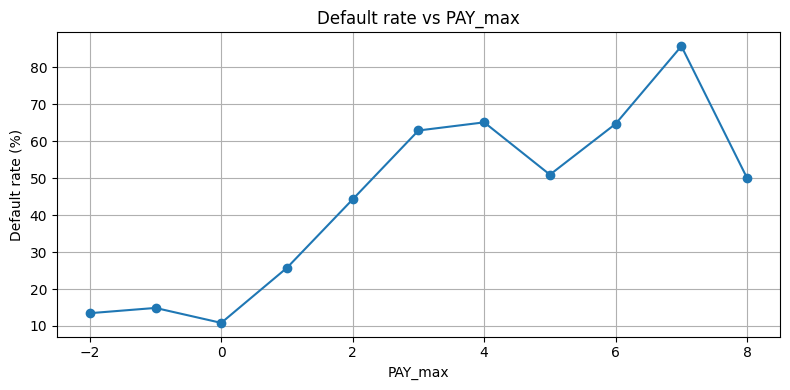

In [66]:
# --- Visualization 1: Default rate vs. PAY (most recent repayment status) ---
plt.figure(figsize=(8,4))

pay_headers = ['PAY_0', 'PAY_2', 'PAY_3',
               'PAY_4', 'PAY_5', 'PAY_6']

train_pay["PAY_max"] = train_pay[pay_headers].max(axis=1)
rate = train_pay.groupby("PAY_max")["target"].mean().sort_index()

plt.plot(rate.index, rate.values * 100, marker="o")

plt.xlabel("PAY_max")
plt.ylabel("Default rate (%)")
plt.title("Default rate vs PAY_max")
plt.grid(True)

plt.tight_layout()
plt.show()


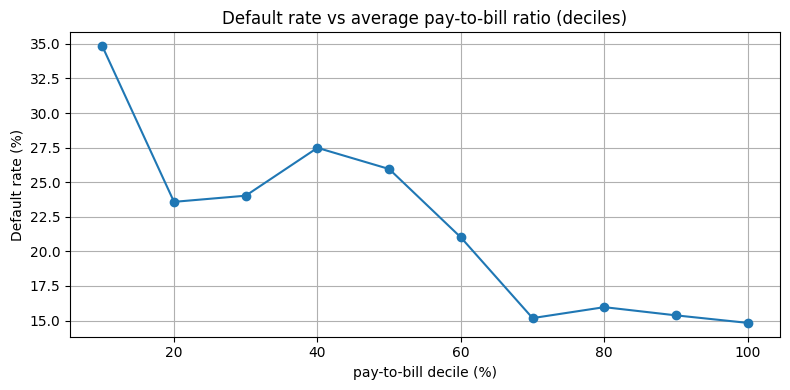

In [94]:
# Visualization 2: Default Rate vs. Average pay-to-bill Ratio
# Credit Utilization = PAY_AMT_avg / BILL_AMT_avg
# Lower ratio correlates to lower payment 

bill_headers = ['BILL_AMT1','BILL_AMT2', 'BILL_AMT3', 
                'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

pay_amt_headers = ['PAY_AMT1','PAY_AMT2', 'PAY_AMT3', 
                   'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

train_pay["BILL_AMT_avg"] = train_pay[bill_headers].mean(axis=1)
train_pay["PAY_AMT_avg"] = train_pay[pay_amt_headers].mean(axis=1)
train_pay["pay_to_bill_ratio"] = train_pay["PAY_AMT_avg"].clip(lower=0) / train_pay["BILL_AMT_avg"].clip(lower=0) 

tmp = train_pay[["target", "pay_to_bill_ratio"]].replace([np.inf, -np.inf], np.nan).dropna()
tmp["decile"] = pd.qcut(tmp["pay_to_bill_ratio"], 10, duplicates="drop")

rate = tmp.groupby("decile", observed=False)["target"].mean()

x = [10*i for i in range(1, len(rate)+1)]

plt.figure(figsize=(8,4))
plt.plot(x, rate.values * 100, marker="o")
plt.xlabel("pay-to-bill decile (%)")
plt.ylabel("Default rate (%)")
plt.title("Default rate vs average pay-to-bill ratio (deciles)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 4. Feature engineering
<hr>
rubric={points:1}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature engineering**: Create new features that are relevant to the problem and use this updated feature set in the following exercises. You may need to iterate between **feature engineering** and **preprocessing** to refine your features and improve model performance.
   
</div>

<div class="alert alert-warning">
    
Solution_4
    
</div>

_Points:_ 1

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 5. Preprocessing and transformations
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Identify feature types**: Determine the different types of features in your dataset (e.g., numerical, categorical, ordinal, text) and specify the transformations you would apply to each type.

2. **Define a column transformer (if needed)**: Implement a `ColumnTransformer` to apply the appropriate preprocessing steps to each feature type.
 
</div>

<div class="alert alert-warning">
    
Solution_5
    
</div>

_Points:_ 10

In [165]:
def features_engineering(X): 
    X_copy = X.copy()

    pay_headers = ['PAY_0', 'PAY_2', 'PAY_3',
                   'PAY_4', 'PAY_5', 'PAY_6']

    bill_headers = ['BILL_AMT1','BILL_AMT2', 'BILL_AMT3', 
                    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

    pay_amt_headers = ['PAY_AMT1','PAY_AMT2', 'PAY_AMT3', 
                       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

    # Feature 1: Max PAY delay per user
    X_copy['PAY_max'] = X_copy[pay_headers].max(axis=1)

    # Feature 2: pay-to-bill Ratio
    X_copy["BILL_AMT_avg"] = X_copy[bill_headers].mean(axis=1)
    X_copy["PAY_AMT_avg"] = X_copy[pay_amt_headers].mean(axis=1)
    # X_copy["pay_to_bill_ratio"] = (X_copy["PAY_AMT_avg"].clip(lower=0) / X_copy["BILL_AMT_avg"]).replace([np.inf, -np.inf], np.nan)

    # # Feature 3: Credit Utilization (BILL_AMT_avg / LIMIT_BAL)
    # X_copy["credit_utilization"] = (X_copy["BILL_AMT_avg"].clip(lower=0) / X_copy["LIMIT_BAL"]).replace([np.inf, -np.inf], np.nan)

    denom_bill = X_copy["BILL_AMT_avg"].replace(0, np.nan)
    X_copy["pay_to_bill_ratio"] = (X_copy["PAY_AMT_avg"].clip(lower=0) / denom_bill)
    X_copy["pay_to_bill_ratio"] = X_copy["pay_to_bill_ratio"].replace([np.inf, -np.inf], np.nan)

    # Feature 3: credit utilization (safe division)
    denom_limit = X_copy["LIMIT_BAL"].replace(0, np.nan)
    X_copy["credit_utilization"] = (X_copy["BILL_AMT_avg"].clip(lower=0) / denom_limit)
    X_copy["credit_utilization"] = X_copy["credit_utilization"].replace([np.inf, -np.inf], np.nan)
    
    # Feature 4: Delinquency Count 

    return X_copy

X_train_features = features_engineering(X_train)
X_test_features =  features_engineering(X_test)

# new_feats = ['PAY_max', 'pay_to_bill_ratio', 'credit_utilization']
# X_train_features[new_feats].describe().round(3)
    

In [166]:
cate_feat = ['MARRIAGE', 'SEX']

ordinal_feat = ['EDUCATION']
ordinal_categories = [[0, 1, 2, 3, 4, 5, 6]]

numeric_feat = [col for col in X_train_features.columns
                if col not in cate_feat + ordinal_feat]

print(f"Numeric features ({len(numeric_feat)}):\n  {numeric_feat}\n")


Numeric features (25):
  ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'PAY_max', 'BILL_AMT_avg', 'PAY_AMT_avg', 'pay_to_bill_ratio', 'credit_utilization']



In [169]:
"""
Numeric Transformer

Imputes data NaN values w/ median of dataset
Scales data using StandardScaler()
"""
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


"""
Categorical Transformer

Imputes data NaN values w/ the most frequent value
Converts data to binary format (OHE)
"""
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

"""
Ordinal Transformer


Imputes data NaN values w/ the most frequent value
Converts data to ordinal format
"""
ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ord', OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_feat),
    ('cat', categorical_transformer, cate_feat),
    ('ord', ordinal_transformer, ordinal_feat)
])

In [170]:
X_train_transformed = preprocessor.fit_transform(X_train_features)
print("Transformed training set shape:", X_train_transformed.shape)

Transformed training set shape: (21000, 32)


In [155]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 6. Baseline model
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Establish a baseline**: Use one of `scikit-learn`’s baseline models (e.g., `DummyClassifier` or `DummyRegressor`, depending on your task) and report the results. This will serve as a reference point for evaluating the performance of your more advanced models.

</div>

<div class="alert alert-warning">
    
Solution_6
    
</div>

_Points:_ 2

In [187]:
scoring = {'roc_auc': 'roc_auc', 'f1': 'f1', 'accuracy': 'accuracy'}

dummy = DummyClassifier(strategy='most_frequent', random_state=123)
dummy_pipe = make_pipeline(preprocessor, dummy)

cv_dummy = cross_validate(dummy_pipe, X_train_features, y_train, cv=5, scoring=scoring)

results = {}
results['DummyClassifier'] = {
    'ROC-AUC (mean)': cv_dummy['test_roc_auc'].mean(),
    'ROC-AUC (std)': cv_dummy['test_roc_auc'].std(),
    'F1 (mean)': cv_dummy['test_f1'].mean(),
    'F1 (std)': cv_dummy['test_f1'].std(),
    'Accuracy (mean)': cv_dummy['test_accuracy'].mean(),
}

print("=== Baseline: DummyClassifier (most_frequent) ===")
pd.DataFrame(results).T.round(4)

=== Baseline: DummyClassifier (most_frequent) ===


,ROC-AUC (mean),ROC-AUC (std),F1 (mean),F1 (std),Accuracy (mean)
DummyClassifier,0.5,0.0,0.0,0.0,0.7768


In [ ]:
...

In [ ]:
...

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 7. Linear models 
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Train a linear model**: Use a linear model as your first real attempt at solving the problem.

2. **Tune hyperparameters**: Perform hyperparameter tuning to explore different values of the model's complexity parameter. 

3. **Evaluate with cross-validation**: Report the cross-validation scores along with their standard deviation.

4. **Summarize findings**: Summarize your results, highlighting key observations from your experiments.

</div>

<div class="alert alert-warning">
    
Solution_7
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

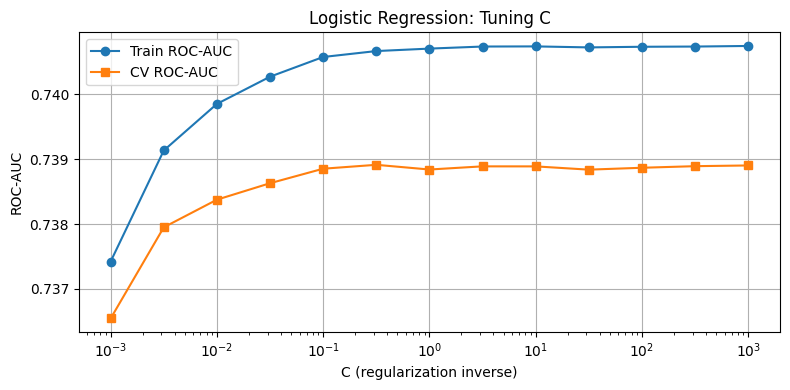

Best C: 1.0000 → CV ROC-AUC: 0.7395


In [185]:
scores_dict = {
    "C": np.logspace(-3, 3, 13),
    "mean_train_scores": list(),
    "mean_cv_scores": list(),
}

for C in scores_dict['C']:
    lr = LogisticRegression(C=C)
    pipe = make_pipeline(preprocessor, lr)
    scores = cross_validate(pipe, X_train_features, y_train, cv=5, 
                            scoring='roc_auc', return_train_score=True)
    scores_dict["mean_train_scores"].append(scores["train_score"].mean())
    scores_dict["mean_cv_scores"].append(scores["test_score"].mean())

results_df = pd.DataFrame(scores_dict)

plt.figure(figsize=(8, 4))
plt.semilogx(scores_dict['C'], scores_dict['mean_train_scores'], marker='o', label='Train ROC-AUC')
plt.semilogx(scores_dict['C'], scores_dict['mean_cv_scores'], marker='s', label='CV ROC-AUC')
plt.xlabel('C (regularization inverse)')
plt.ylabel('ROC-AUC')
plt.title('Logistic Regression: Tuning C')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

best_C = scores_dict['C'][np.argmax(cv_scores)]
print(f"Best C: {best_C:.4f} → CV ROC-AUC: {max(cv_scores):.4f}")


In [191]:
# Final Logistic Regression with best C
lr_best = LogisticRegression(C=best_C)
lr_pipe = make_pipeline(preprocessor, lr_best)

cv_lr = cross_validate(lr_pipe, X_train_features, y_train, cv=5,
                       scoring=scoring, return_train_score=True)

results['LogisticRegression'] = {
    'ROC-AUC (mean)': cv_lr['test_roc_auc'].mean(),
    'ROC-AUC (std)': cv_lr['test_roc_auc'].std(),
    'F1 (mean)': cv_lr['test_f1'].mean(),
    'F1 (std)': cv_lr['test_f1'].std(),
    'Accuracy (mean)': cv_lr['test_accuracy'].mean(),
}

# display(results)

print(f"=== Logistic Regression (C={best_C:.4f}, balanced) ===")
print(f"CV ROC-AUC: {cv_lr['test_roc_auc'].mean():.4f} ± {cv_lr['test_roc_auc'].std():.4f}")
print(f"CV F1:      {cv_lr['test_f1'].mean():.4f} ± {cv_lr['test_f1'].std():.4f}")
print(f"CV Accuracy:{cv_lr['test_accuracy'].mean():.4f} ± {cv_lr['test_accuracy'].std():.4f}")


=== Logistic Regression (C=1.0000, balanced) ===
CV ROC-AUC: 0.7388 ± 0.0086
CV F1:      0.3490 ± 0.0229
CV Accuracy:0.8057 ± 0.0031


In [195]:
# Examine top logistic regression coefficients
lr_pipe.fit(X_train_features, y_train)

# Get feature names from preprocessor
ohe_feat = (lr_pipe.named_steps['columntransformer']
                .named_transformers_['cat']
                .named_steps['ohe']
                .get_feature_names_out(cate_feat).tolist())
ord_feat = ordinal_feat.copy()
all_feature_names = numeric_feat + ohe_feat + ord_feat

coef_df = (pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": lr_pipe.named_steps["logisticregression"].coef_[0]
})
.sort_values("coefficient", key=lambda s: s.abs(), ascending=False))

print("Top 15 most influential features (Logistic Regression):")
print(coef_df.head(15).to_string(index=False))


Top 15 most influential features (Logistic Regression):
    feature  coefficient
 MARRIAGE_0    -0.675152
    PAY_max     0.473003
      SEX_2    -0.437313
      PAY_0     0.409158
  BILL_AMT1    -0.352488
      SEX_1    -0.293740
  BILL_AMT2     0.185352
   PAY_AMT1    -0.175961
PAY_AMT_avg    -0.138219
   PAY_AMT2    -0.136596
 MARRIAGE_2    -0.135661
  LIMIT_BAL    -0.127910
  EDUCATION    -0.087185
   PAY_AMT3    -0.077443
  BILL_AMT3     0.073672


In [ ]:
...

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 8. Different models
<hr>
rubric={points:12}

<div class="alert alert-info">
    
**Your tasks:**

1. **Experiment with additional models**: Train at least **three models** other than a linear model. Ensure that **at least one** of these models is a **tree-based ensemble model** (e.g., Random Forest, Gradient Boosting, or XGBoost).

2. **Compare and interpret results**: Summarize your findings in terms of **overfitting/underfitting** behavior and **fit/score times** for each model. Reflect on your results. Were you able to **outperform the linear model**?

</div>

<div class="alert alert-warning">
    
Solution_8
    
</div>

_Points:_ 12

_Type your answer here, replacing this text._

In [204]:
import time

models = {
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'DecisionTree': DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=123),
    'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=123, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=123),
}

for name, model in models.items():
    pipe = make_pipeline(preprocessor, model)
    t0 = time.time()
    cv = cross_validate(pipe, X_train_features, y_train, cv=5,
                        scoring=scoring, return_train_score=True)
    elapsed = time.time() - t0
    
    results[name] = {
        'ROC-AUC (mean)': cv['test_roc_auc'].mean(),
        'ROC-AUC (std)': cv['test_roc_auc'].std(),
        'F1 (mean)': cv['test_f1'].mean(),
        'F1 (std)': cv['test_f1'].std(),
        'Accuracy (mean)': cv['test_accuracy'].mean(),
        'Train ROC-AUC': cv['train_roc_auc'].mean(),
        'CV Time (s)': round(elapsed, 1),
    }
    print(f"{name:20s} | ROC-AUC: {cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.4f} | "
          f"F1: {cv['test_f1'].mean():.4f} | Time: {elapsed:.1f}s")


KNN                  | ROC-AUC: 0.7562 ± 0.0078 | F1: 0.4382 | Time: 2.9s
DecisionTree         | ROC-AUC: 0.6179 ± 0.0098 | F1: 0.4113 | Time: 1.7s
RandomForest         | ROC-AUC: 0.7658 ± 0.0044 | F1: 0.4570 | Time: 7.0s
GradientBoosting     | ROC-AUC: 0.7774 ± 0.0062 | F1: 0.4761 | Time: 78.1s


In [199]:
# Summary table of all models so far
summary_df = pd.DataFrame(results).T[['ROC-AUC (mean)', 'ROC-AUC (std)', 'F1 (mean)', 'F1 (std)', 'Accuracy (mean)']].round(4)
summary_df.sort_values('ROC-AUC (mean)', ascending=False)

,ROC-AUC (mean),ROC-AUC (std),F1 (mean),F1 (std),Accuracy (mean)
GradientBoosting,0.7774,0.0062,0.4761,0.0129,0.8182
RandomForest,0.7658,0.0044,0.4570,0.0145,0.8151
KNN,0.7453,0.0066,0.4484,0.0061,0.8086
DecisionTree,0.7426,0.0065,0.5087,0.0090,0.7282
LogisticRegression,0.7388,0.0086,0.3490,0.0229,0.8057
DummyClassifier,0.5000,0.0000,0.0000,0.0000,0.7768


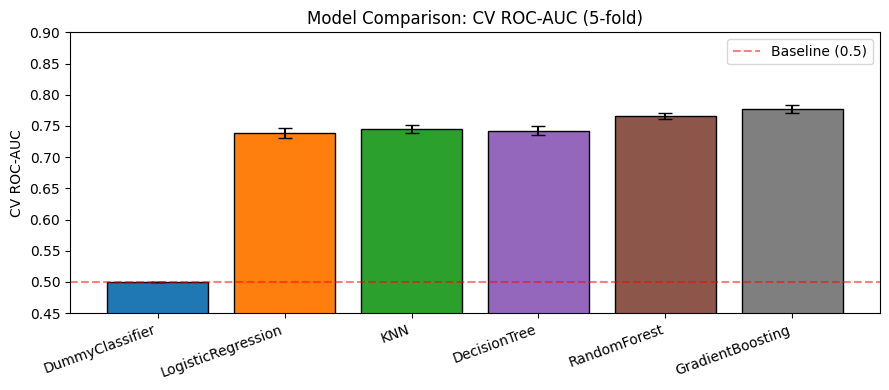

In [200]:
# Visualise ROC-AUC comparison
model_names = list(results.keys())
auc_means = [results[m]['ROC-AUC (mean)'] for m in model_names]
auc_stds  = [results[m]['ROC-AUC (std)']  for m in model_names]

fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.tab10(np.linspace(0, 0.7, len(model_names)))
bars = ax.bar(model_names, auc_means, yerr=auc_stds, capsize=5, color=colors, edgecolor='black')
ax.set_ylabel('CV ROC-AUC')
ax.set_title('Model Comparison: CV ROC-AUC (5-fold)')
ax.set_ylim(0.45, 0.90)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Baseline (0.5)')
plt.xticks(rotation=20, ha='right')
ax.legend(); plt.tight_layout(); plt.show()


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 9. Feature selection 
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature selection**: Attempt to select relevant features using methods such as `RFECV` or forward selection.

2. **Evaluate the impact** Compare the model performance before and after feature selection. Do the results improve with feature selection?

3. **Summarize findings** Summarize your observations and decide whether to **keep feature selection** in your pipeline.  If it improves results, retain it for the next exercises; otherwise, you may choose to omit it.
</div>

<div class="alert alert-warning">
    
Solution_9
    
</div>

_Points:_ 2

_Type your answer here, replacing this text._

Optimal number of features: 17
Best CV ROC-AUC (RFECV internal): 0.7398


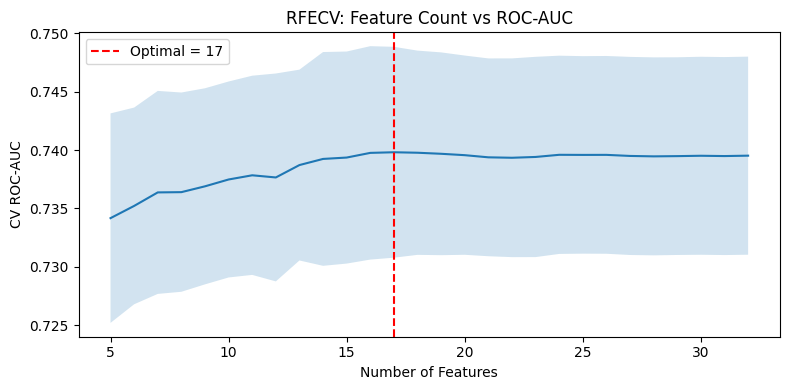

In [205]:
from sklearn.feature_selection import RFECV

# Build a preprocessor that outputs a dataframe-friendly array first
preprocessor_for_rfe = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_feat),
    ('cat', categorical_transformer, cate_feat),
    ('ord', ordinal_transformer, ordinal_feat)
])

# Use a fast LR for RFECV
lr_for_rfe = LogisticRegression(C=best_C, class_weight='balanced', max_iter=1000, random_state=123)

rfecv = RFECV(
    estimator=lr_for_rfe,
    step=1,
    cv=5,
    scoring='roc_auc',
    min_features_to_select=5,
    n_jobs=-1
)

rfe_pipe = Pipeline([
    ('preprocessor', preprocessor_for_rfe),
    ('rfecv', rfecv)
])

rfe_pipe.fit(X_train_features, y_train)

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Best CV ROC-AUC (RFECV internal): {rfecv.cv_results_['mean_test_score'].max():.4f}")

# Plot number of features vs CV score
plt.figure(figsize=(8, 4))
n_feats = range(rfecv.min_features_to_select, len(rfecv.cv_results_['mean_test_score']) + rfecv.min_features_to_select)
plt.plot(n_feats, rfecv.cv_results_['mean_test_score'])
plt.fill_between(n_feats,
                 rfecv.cv_results_['mean_test_score'] - rfecv.cv_results_['std_test_score'],
                 rfecv.cv_results_['mean_test_score'] + rfecv.cv_results_['std_test_score'],
                 alpha=0.2)
plt.xlabel('Number of Features')
plt.ylabel('CV ROC-AUC')
plt.title('RFECV: Feature Count vs ROC-AUC')
plt.axvline(rfecv.n_features_, color='red', linestyle='--', label=f'Optimal = {rfecv.n_features_}')
plt.legend(); plt.tight_layout(); plt.show()


In [207]:
# Get names of selected features
ohe_features_list = (preprocessor_for_rfe.named_transformers_['cat']
                     .named_steps['ohe']
                     .get_feature_names_out(cate_feat).tolist())
all_feat_names_rfe = numeric_fea + ohe_features_list + ordinal_features

selected_mask = rfecv.support_
selected_features = [f for f, s in zip(all_feat_names_rfe, selected_mask) if s]
print(f"Selected features ({len(selected_features)}):")
print(selected_features)


NameError: name 'numeric_features' is not defined

In [ ]:
...

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 10. Hyperparameter optimization
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Optimize hyperparameters**: Attempt to optimize hyperparameters for the models you have tried so far. In at least **one case**, tune **multiple hyperparameters** for a single model.

2. **Use suitable optimization methods**: You may use any of the following approaches for hyperparameter optimization:
   - [`GridSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)  
   - [`RandomizedSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)  
   - [Bayesian optimization with scikit-optimize](https://github.com/scikit-optimize/scikit-optimize)

3. **Summarize your results**: Report and compare the optimized results across models. Discuss whether hyperparameter optimization led to performance improvements.

</div>

<div class="alert alert-warning">
    
Solution_10
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 11. Interpretation and feature importances
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Interpret model feature importance**: Use one of the interpretation methods discussed in class (e.g., `shap`), or another suitable method of your choice, to examine the most important features of one of your **non-linear models**.

2. **Summarize insights**: Summarize your observations about which features contribute most to the model's predictions and how they influence the outcomes.

   
</div>

<div class="alert alert-warning">
    
Solution_11
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 12. Results on the test set
<hr>

rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Evaluate on the test set**: Apply your best-performing model to the test data and report the test scores.

2. **Compare and reflect**: Compare the **test scores** with the **validation scores** from previous experiments. Discuss the consistency between them. How much do you **trust your results**? Reflect on whether you might have encountered **optimization bias**.

3. **Explain individual predictions**: Select one or two examples from your test predictions and use an interpretation method (e.g., **SHAP force plots**) to explain these individual predictions.
</div>

<div class="alert alert-warning">
    
Solution_12
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 13. Summary of results
<hr>
rubric={points:12}

Imagine you are preparing to present the summary of your results to your boss and co-workers.

<div class="alert alert-info">
    
**Your tasks:**

1. **Summarize key results**: Create a clear and concise table highlighting your most important results (e.g., models compared, validation/test scores, key observations).

2. **Write concluding remarks**: Summarize your main takeaways from the project, including what worked well and what did not.

3. **Propose future improvements**: Discuss ideas or approaches you did not try but that could potentially improve **performance** or **interpretability**.

4. **Report final results**: Report your **final test score** and the **metric** you used.

</div>


<div class="alert alert-warning">
    
Solution_13
    
</div>

_Points:_ 12

_Type your answer here, replacing this text._

In [ ]:
...

In [ ]:
...

<!-- END QUESTION -->

<br><br>

<br><br>

<!-- BEGIN QUESTION -->

## 14. Your takeaway
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

What is your biggest takeaway from the supervised machine learning material we have learned so far? Please write thoughtful answers.  

</div>

<div class="alert alert-warning">
    
Solution_14
    
</div>

_Points:_ 2

<!-- END QUESTION -->

<br><br>

Before submitting your assignment, please ensure you have followed all the steps in the **Instructions** section at the top.  

### Submission checklist  

- [ ] Restart the kernel and run all cells (▶▶ button)
- [ ] Make sure to push the most up to date version of your homework assignment to your GitHub repository so that we can use it for grading if there are any problems with your submission on Gradescope. 
- [ ] The `.ipynb` file runs without errors and shows all outputs.  
- [ ] Only the `.ipynb` file and required output files are uploaded (no extra files).  
- [ ] If the `.ipynb` file is too large to render on Gradescope, upload a Web PDF and/or HTML version as well.


This was a tricky one but you did it 👏👏!  

![](img/eva-well-done.png)